In [205]:
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import pandas as pd
import os
import mne

In [313]:
"""
In this notebook, we analyze electric artifacts from the LIFU Headset. No preprocessing occurs before windowing to ensure we can capture artifacts
All channel STFTs are averaged into one PSD graph per epoch.  
"""

'\nIn this notebook, we analyze electric artifacts from the LIFU Headset. No preprocessing occurs before windowing to ensure we can capture artifacts\nAll channel STFTs are averaged into one PSD graph per epoch.  \n'

In [315]:
# full eeg
full_eeg = pd.read_csv("offline_2back_active.csv")
full_eeg

,Time,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08
0,0.000,37356.855469,4304.361816,-12081.099609,55824.781250,12688.781250,35765.335938,44322.355469,474.047699
1,0.004,37202.957031,4088.425781,-12049.771484,55723.980469,12596.273438,35702.992188,44172.292969,472.140320
2,0.008,36667.425781,4296.064941,-10897.184570,55719.355469,12492.325195,35182.929688,44320.843750,474.977539
3,0.012,36776.667969,4521.608398,-10907.435547,55782.730469,12561.656250,35204.312500,44452.312500,473.189392
4,0.016,37258.867188,4350.471680,-11909.176758,55780.199219,12667.083984,35668.062500,44320.843750,473.833160
...,...,...,...,...,...,...,...,...,...
93540,374.160,38285.832031,6078.577148,-9492.921875,51052.312500,14522.671875,37070.300781,45966.324219,473.976166
93541,374.164,37745.835938,6282.664062,-8242.512695,51018.718750,14396.215820,36561.230469,46138.429688,471.758881
93542,374.168,37685.875000,6644.320312,-7787.943848,51080.613281,14445.401367,36391.261719,46392.925781,470.519135
93543,374.172,38178.898438,6484.246094,-8878.445312,51116.832031,14568.615234,36857.988281,46252.355469,473.380127


In [316]:
# windows = pd.read_csv("all_windows.csv")
# window_id = 4 #automate
# windows
#full_eeg = full_eeg[66:-1].reset_index(drop = True)
#full_eeg[32930:32935]

In [317]:
markers 

,Time,marker,LSL_timestamp
0,2.686235,collecting_baseline,1.002150e+06
1,2.723118,collecting_baseline,1.002150e+06
2,2.756129,collecting_baseline,1.002150e+06
3,2.799655,collecting_baseline,1.002150e+06
4,2.829432,collecting_baseline,1.002150e+06
...,...,...,...
201,131.477770,START_EXPERIMENT_RECEIVED,1.002279e+06
202,131.819562,LIFU_ON,1.002279e+06
203,136.830203,LIFU_OFF,1.002284e+06
204,358.441138,LIFU_ON,1.002506e+06


In [328]:
#LIFU onset
markers = pd.read_csv('lifu_markers_1_2back_active.csv')
lifu_on = markers[markers['marker'] == "LIFU_ON"]
lifu_on = np.array(lifu_on['Time'])
lifu_on

array([131.819562, 358.441138])

In [345]:
# windowing around LIFU Onset
pre = 5
post = 10
raw_windows = []
target_ts_onset = lifu_on
raw = full_eeg

for idx, event in enumerate(lifu_on): 
    mask = (raw['Time'] >= (event - pre)) & (raw['Time'] <= (event + post))
    window_df = raw.loc[mask].copy()
    window_df["t_rel"] = window_df["Time"] - event 
    window_df["idx"] = idx
    raw_windows.append(window_df)
raw_windows[0]

,Time,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08,t_rel,idx
31705,126.820,37469.242188,4249.596680,-12942.482422,58058.605469,13129.115234,36099.699219,44303.179688,472.402588,-4.999562,0
31706,126.824,37079.406250,4481.983398,-11089.731445,58044.488281,13126.802734,35742.710938,44545.707031,472.903259,-4.995562,0
31707,126.828,36580.875000,5555.105469,-8305.979492,58116.613281,13221.122070,34929.679688,45323.062500,471.210541,-4.991562,0
31708,126.832,36961.867188,5389.595215,-10068.965820,58125.667969,13224.125000,35268.000000,45121.812500,471.758881,-4.987562,0
31709,126.836,37450.511719,4350.447754,-12865.973633,58059.960938,13133.551758,36039.593750,44371.394531,473.284760,-4.983562,0
...,...,...,...,...,...,...,...,...,...,...,...
35450,141.800,37640.550781,4876.876465,-12063.599609,58591.867188,13270.164062,36105.019531,44646.000000,474.810638,9.980438,0
35451,141.804,37573.335938,4519.010254,-11888.671875,58556.937500,13230.919922,36218.167969,44442.773438,472.497986,9.984438,0
35452,141.808,36990.792969,5421.709961,-8785.843750,58601.457031,13291.098633,35456.519531,45147.613281,472.021149,9.988438,0
35453,141.812,37033.179688,5874.514648,-8750.248047,58642.605469,13339.497070,35284.500000,45420.312500,470.900574,9.992438,0


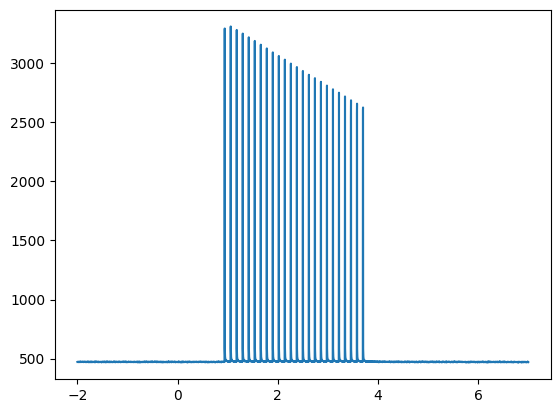

In [346]:

# sanity check that channel 8 recorded triggers properly
channel_8 = np.array(raw_windows[0][' Ch08'])
n = len(channel_8)   # 2246 samples
t = np.linspace(-2, 7, n)
plt.plot(t, channel_8)

In [347]:
df

,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07
63000,38198.468750,5416.107910,-11431.075195,58545.261719,14055.278320,37013.648438,45379.144531
63001,37840.730469,5640.889160,-9664.989258,58535.718750,14056.849609,36688.117188,45620.468750
63002,37337.449219,6684.494629,-6931.592285,58575.898438,14143.325195,35897.804688,46407.417969
63003,37696.292969,6530.500000,-8631.708008,58586.988281,14144.135742,36216.480469,46206.363281
63004,38184.835938,5520.678223,-11340.833984,58553.605469,14066.005859,36963.460938,45444.398438
...,...,...,...,...,...,...,...
64246,38159.230469,5379.843750,-11225.963867,58555.488281,14089.825195,37025.312500,45377.542969
64247,37680.300781,5921.936523,-8755.161133,58560.519531,14124.083984,36479.261719,45849.542969
64248,37376.792969,6804.132812,-7020.092773,58598.074219,14202.333984,35888.988281,46483.832031
64249,37852.625000,6339.812500,-9342.193359,58600.144531,14178.159180,36418.031250,46063.144531


In [348]:
import numpy as np
import mne

sfreq = 250

all_epochs = []

for idx in range(len(raw_windows)):
    df = raw_windows[idx].copy()
    df.columns = df.columns.str.strip()

    # Drop non‑EEG columns
    df = df.drop(['Time', 't_rel', 'idx', 'Ch08'], axis=1)

    # Convert to numpy (n_channels × n_times)
    data = df.to_numpy().T

    all_epochs.append(data)

# Stack into shape (n_epochs, n_channels, n_times)
all_epochs = np.stack(all_epochs, axis=0)

# Channel names and types
ch_names = list(df.columns)
ch_types = ['eeg'] * len(ch_names)

# Create info
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# Create MNE Epochs object
epochs = mne.EpochsArray(all_epochs, info)


Not setting metadata
2 matching events found
No baseline correction applied
0 projection items activated


Number of frequencies: 129
Number of time steps: 59


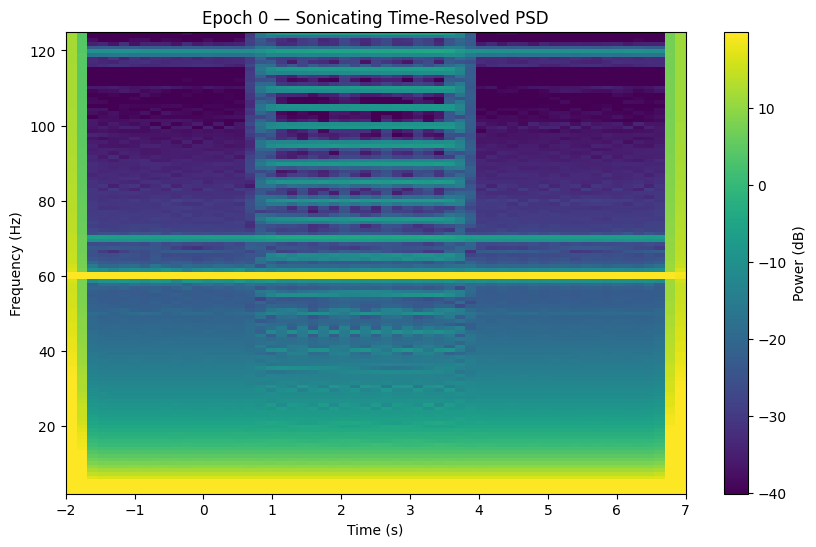

Number of frequencies: 129
Number of time steps: 59


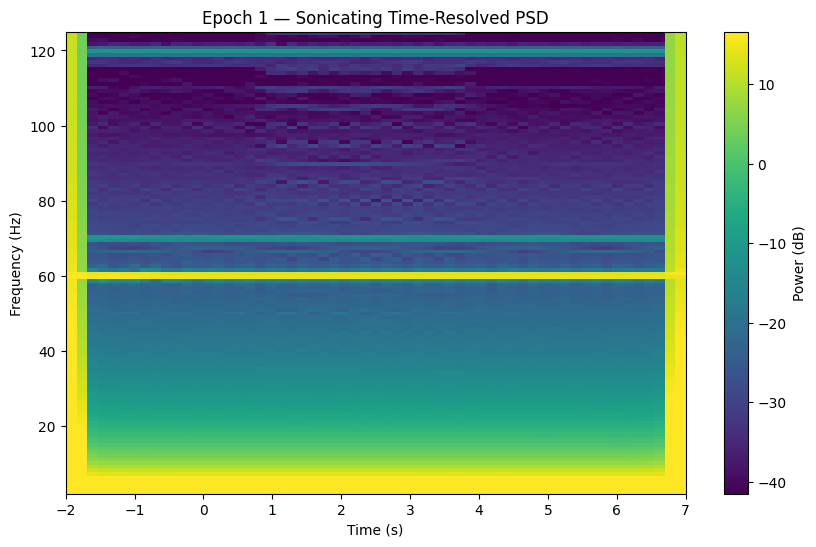

In [349]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt

sfreq = epochs.info['sfreq']
tmin = -2
tmax = 7

data_all = epochs.get_data()   # shape: (n_epochs, n_channels, n_times)

all_spectrograms = []
all_times = []
all_freqs = []

for idx in range(len(data_all)):

    # ep shape: (n_channels, n_times)
    ep = data_all[idx].astype(float)

    data = ep #* 1e-6

    # stft params
    n_fft = 256
    step = 64
    
    Zxx = stft(data, wsize=n_fft, tstep=step)
    power = np.abs(Zxx)**2 / (n_fft**2)

    # time axis
    times = np.linspace(tmin, tmax, power.shape[-1])

    # frequency axis 
    freqs = np.linspace(0, sfreq/2, power.shape[1])

    # select all freqs
    mask = (freqs >= 1) 
    freqs_1_40 = freqs[mask]
    power_1_40 = power[:, mask, :]

    # one graph per epoch
    psd_avg = power_1_40.mean(axis=0)

    # db for better visualization
    psd_db = 10 * np.log10(psd_avg + 1e-20)

    vmin = np.percentile(psd_db, 5)
    vmax = np.percentile(psd_db, 95)

    all_spectrograms.append(psd_db)
    all_times.append(times)
    all_freqs.append(freqs_1_40)

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.imshow(
        psd_db,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], freqs_1_40[0], freqs_1_40[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Epoch {idx} — Sonicating Time‑Resolved PSD")
    plt.colorbar(label="Power (dB)")
    plt.show()


In [350]:
#no sonication windowing
times = [175, 250] # random non sonciation times
# windowing
pre = 5
post = 15
raw_windows_ns = []
target_ts_onset = times
raw = full_eeg

for idx, event in enumerate(target_ts_onset): 
    mask = (raw['Time'] >= (event - pre)) & (raw['Time'] <= (event + post))
    window_df = raw.loc[mask].copy()
    window_df["t_rel"] = window_df["Time"] - event 
    window_df["idx"] = idx
    raw_windows_ns.append(window_df)
raw_windows_ns[0]

,Time,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08,t_rel,idx
42500,170.000,37084.105469,5700.898438,-8333.373047,59069.113281,13560.843750,35637.761719,45533.761719,468.707123,-5.000,0
42501,170.004,37132.906250,6138.396973,-8367.801758,59106.574219,13608.242188,35481.457031,45788.792969,470.805176,-4.996,0
42502,170.008,37676.863281,5312.849121,-11278.034180,59068.707031,13536.882812,36192.542969,45129.562500,470.399902,-4.992,0
42503,170.012,37750.218750,4748.846191,-11805.343750,59030.636719,13485.481445,36485.648438,44768.980469,471.830414,-4.988,0
42504,170.016,37180.500000,5503.773438,-8870.817383,59059.312500,13543.559570,35789.250000,45389.613281,470.709869,-4.984,0
...,...,...,...,...,...,...,...,...,...,...,...
47496,189.984,37045.363281,6238.460938,-7461.214844,59302.500000,13684.989258,35517.648438,45937.304688,469.946930,14.984,0
47497,189.988,37393.480469,6114.721680,-9108.973633,59310.156250,13680.387695,35812.480469,45758.031250,471.830414,14.988,0
47498,189.992,37910.707031,5102.252930,-11929.726562,59265.398438,13607.646484,36581.492188,44999.054688,469.541595,14.992,0
47499,189.996,37667.492188,5048.584961,-10809.661133,59244.679688,13586.593750,36443.738281,45042.492188,470.495270,14.996,0


In [351]:
import numpy as np
import mne

sfreq = 250

all_epochs = []

for idx in range(len(raw_windows_ns)):
    df = raw_windows_ns[idx].copy()
    df.columns = df.columns.str.strip()

    # Drop non‑EEG columns
    df = df.drop(['Time', 't_rel', 'idx', 'Ch08'], axis=1)

    # Convert to numpy (n_channels × n_times)
    data = df.to_numpy().T

    all_epochs.append(data)

# Stack into shape (n_epochs, n_channels, n_times)
all_epochs = np.stack(all_epochs, axis=0)

# Channel names and types
ch_names = list(df.columns)
ch_types = ['eeg'] * len(ch_names)

# Create info
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# Create MNE Epochs object
epoch_ns = mne.EpochsArray(all_epochs, info)


Not setting metadata
2 matching events found
No baseline correction applied
0 projection items activated


Number of frequencies: 129
Number of time steps: 79


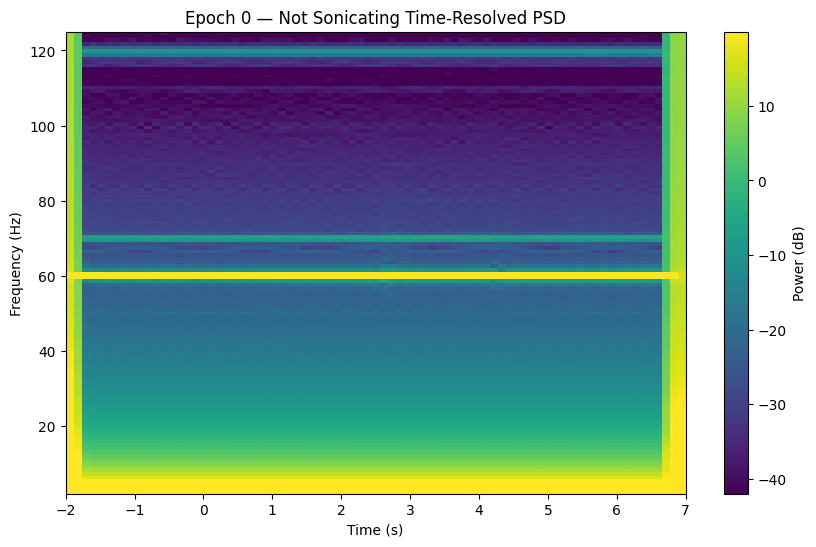

Number of frequencies: 129
Number of time steps: 79


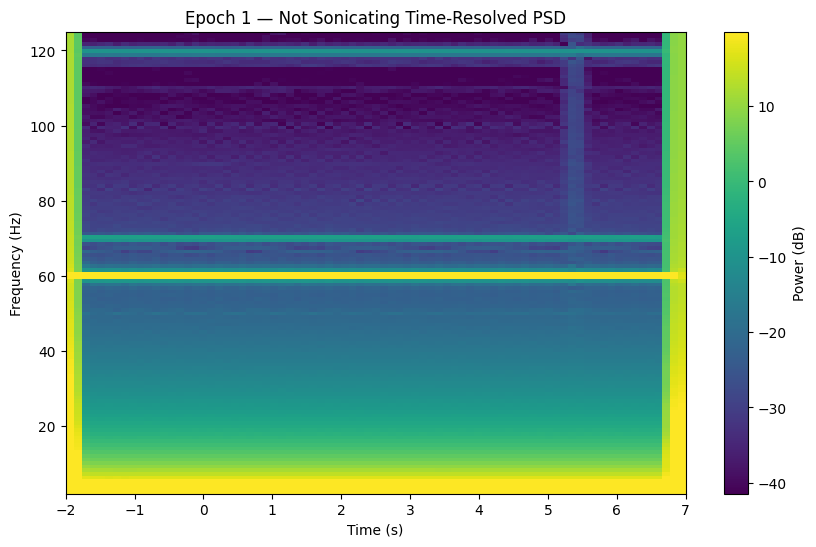

In [352]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt

# --- Extract everything BEFORE the loop ---
sfreq = epoch_ns.info['sfreq']
tmin = -2
tmax = 7

data_all = epoch_ns.get_data()   # shape: (n_epochs, n_channels, n_times)

all_spectrograms = []
all_times = []
all_freqs = []

for idx in range(len(data_all)):

    # ep shape: (n_channels, n_times)
    ep = data_all[idx].astype(float)

    # µV → V
    data = ep # * 1e-6

    # --- STFT parameters ---
    n_fft = 256
    step = 64

    # --- Compute STFT ---
    Zxx = stft(data, wsize=n_fft, tstep=step)
    power = np.abs(Zxx)**2 / (n_fft**2)

    # --- Time axis ---
    times = np.linspace(tmin, tmax, power.shape[-1])

    # --- Frequency axis ---
    freqs = np.linspace(0, sfreq/2, power.shape[1])

    # --- Select 1–40 Hz ---
    mask = (freqs >= 1) 
    freqs_1_40 = freqs[mask]
    power_1_40 = power[:, mask, :]

    # --- Average across channels ---
    psd_avg = power_1_40.mean(axis=0)

    # --- Convert to dB ---
    psd_db = 10 * np.log10(psd_avg + 1e-20)

    # --- Clip color range ---
    vmin = np.percentile(psd_db, 5)
    vmax = np.percentile(psd_db, 95)

    # --- Store ---
    all_spectrograms.append(psd_db)
    all_times.append(times)
    all_freqs.append(freqs_1_40)

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.imshow(
        psd_db,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], freqs_1_40[0], freqs_1_40[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Epoch {idx} — Not Sonicating Time‑Resolved PSD")
    plt.colorbar(label="Power (dB)")
    plt.show()
